In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
df = pd.read_csv('data\Motor vehicle insurance data.csv',sep=';')

In [14]:
df

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.00,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.00,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.00,0,P,NaN,190
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.00,0,P,NaN,190
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.00,0,P,NaN,190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105550,53498,30/07/2018,30/07/2018,30/07/2019,25/07/1981,14/02/2007,0,1,1,1,...,0,0,2000,110,1997,24320.00,5,D,4.740,1480
105551,53499,16/08/2018,16/08/2018,16/08/2019,08/12/1976,29/11/2017,0,1,1,1,...,0,0,2013,129,1998,30861.97,5,P,4.650,1440
105552,53500,21/11/2018,21/11/2018,21/11/2019,01/04/1974,05/10/2011,0,1,1,1,...,0,0,1999,55,999,7800.00,5,P,3.495,830
105553,53501,21/11/2018,21/11/2018,21/11/2019,15/09/1946,02/02/1982,0,1,1,1,...,0,0,2004,90,1753,16610.00,5,D,4.555,1399


In [159]:
df = df.sort_values(["ID", "Date_start_contract"])

train_list = []
test_list = []

# prvo nađi unique ID-eve (gde je samo 1 red)
group_sizes = df.groupby("ID").size()
single_ids = group_sizes[group_sizes == 1].index

# random 20% tih ID-eva
np.random.seed(42)  # zbog reprodukcije
test_single_ids = np.random.choice(single_ids, 
                                   size=int(0.2 * len(single_ids)), 
                                   replace=False)

for id_val, group in df.groupby("ID"):
    if len(group) == 1:
        if id_val in test_single_ids:
            test_list.append(group)
        else:
            train_list.append(group)
    else:
        train_list.append(group.iloc[:-1])
        test_list.append(group.iloc[-1:])

train = pd.concat(train_list)
test = pd.concat(test_list)

In [40]:
train.to_csv("data/train.csv", index=False)
test.to_csv("data/test.csv", index=False)

In [61]:
df_id_1 = df[df["ID"] == 1]

In [77]:
df_id_1[['Date_last_renewal','Date_next_renewal','N_claims_history','Premium','Power']]

,Date_last_renewal,Date_next_renewal,N_claims_history,Premium,Power
0,05/11/2015,05/11/2016,0,222.52,80
1,05/11/2016,05/11/2017,0,213.78,80
2,05/11/2017,05/11/2018,0,214.84,80
3,05/11/2018,05/11/2019,0,216.99,80


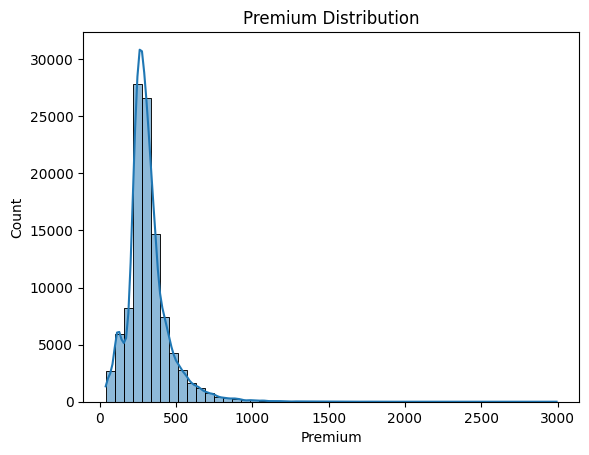

In [88]:
sns.histplot(df['Premium'], bins=50, kde=True)

plt.title("Premium Distribution")
plt.savefig("slike\Distribucija Premium.png")
plt.show()

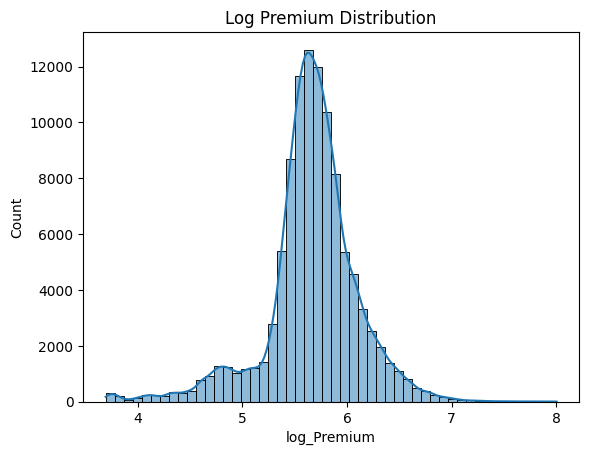

In [86]:
sns.histplot(df["log_Premium"], bins=50, kde=True)

plt.title("Log Premium Distribution")
plt.savefig("slike\Distribucija Premium.png")
plt.show()

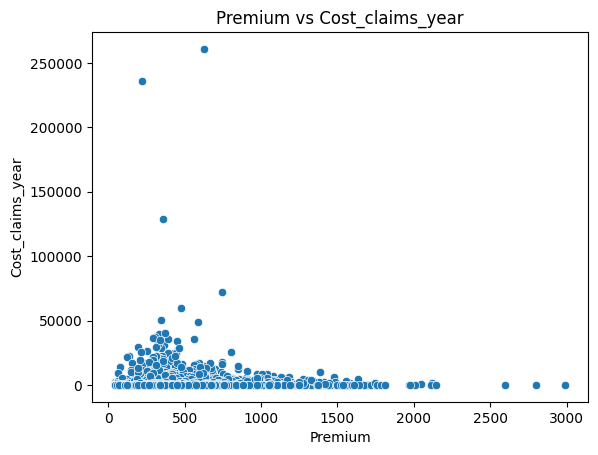

In [89]:


sns.scatterplot(x="Premium", y="Cost_claims_year", data=df)

plt.title("Premium vs Cost_claims_year")
plt.savefig("slike\Odnos Premium-a i cene stete za polisu.png")
plt.show()

In [78]:
df_power_change = df.groupby("ID")["Power"].nunique()

# uzmi samo one gde ima više različitih vrednosti
ids_with_change = df_power_change[df_power_change > 1].index

# filtriraj originalni df
df_changed = df[df["ID"].isin(ids_with_change)]

In [79]:
df_changed

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight,log_Premium


In [83]:
df['Premium'].mean()

np.float64(315.8925572450381)

In [90]:
df

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight,log_Premium
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,2004,80,599,7068.00,0,P,NaN,190,5.405017
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,2004,80,599,7068.00,0,P,NaN,190,5.364947
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,2004,80,599,7068.00,0,P,NaN,190,5.369894
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,...,0,2004,80,599,7068.00,0,P,NaN,190,5.379851
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,2004,80,599,7068.00,0,P,NaN,190,5.364573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105550,53498,30/07/2018,30/07/2018,30/07/2019,25/07/1981,14/02/2007,0,1,1,1,...,0,2000,110,1997,24320.00,5,D,4.740,1480,5.575153
105551,53499,16/08/2018,16/08/2018,16/08/2019,08/12/1976,29/11/2017,0,1,1,1,...,0,2013,129,1998,30861.97,5,P,4.650,1440,6.037799
105552,53500,21/11/2018,21/11/2018,21/11/2019,01/04/1974,05/10/2011,0,1,1,1,...,0,1999,55,999,7800.00,5,P,3.495,830,6.348982
105553,53501,21/11/2018,21/11/2018,21/11/2019,15/09/1946,02/02/1982,0,1,1,1,...,0,2004,90,1753,16610.00,5,D,4.555,1399,5.827945


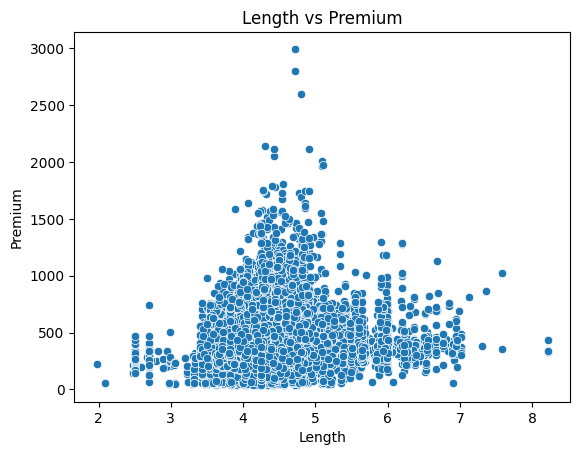

In [107]:
sns.scatterplot(x="Length", y="Premium", data=df)

plt.title("Length vs Premium")
plt.show()

In [106]:
df["length_bin"] = pd.qcut(df["Length"], q=5)

df.groupby("length_bin")["Premium"].mean()

C:\Users\Pc\AppData\Local\Temp\ipykernel_736\4094528413.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("length_bin")["Premium"].mean()


length_bin
(1.977, 3.97]     298.574952
(3.97, 4.188]     313.670456
(4.188, 4.276]    252.767353
(4.276, 4.479]    353.848574
(4.479, 8.218]    366.943382
Name: Premium, dtype: float64

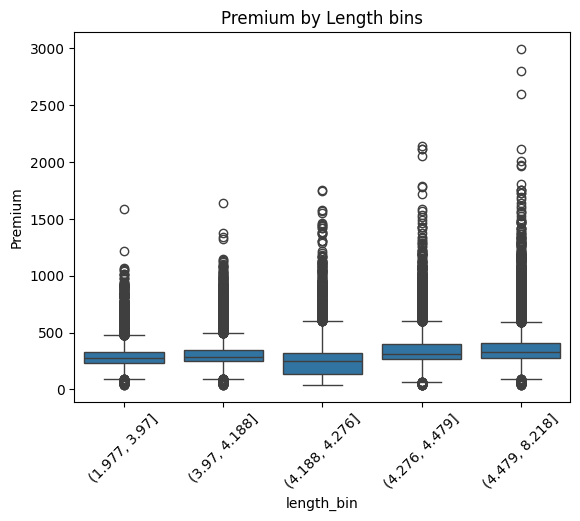

In [108]:
sns.boxplot(x="length_bin", y="Premium", data=df)

plt.xticks(rotation=45)
plt.title("Premium by Length bins")
plt.show()

In [105]:
df["Length"] = df["Length"].fillna(df["Length"].mean())

<Axes: xlabel='length_power', ylabel='log_Premium'>

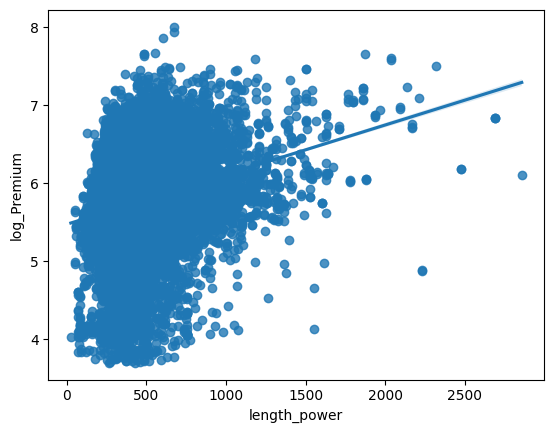

In [103]:
sns.regplot(x="length_power", y="log_Premium", data=df)

In [153]:
cars["length_power"] = cars["Length"] * cars["Power"]

In [155]:
cars[["length_power", "log_Premium"]].corr()

KeyError: "['log_Premium'] not in index"

In [113]:
df

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight,log_Premium,length_bin,length_power
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,80,599,7068.00,0,P,4.252007,190,5.405017,"(4.188, 4.276]",340.160599
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,80,599,7068.00,0,P,4.252007,190,5.364947,"(4.188, 4.276]",340.160599
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,80,599,7068.00,0,P,4.252007,190,5.369894,"(4.188, 4.276]",340.160599
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,...,80,599,7068.00,0,P,4.252007,190,5.379851,"(4.188, 4.276]",340.160599
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,...,80,599,7068.00,0,P,4.252007,190,5.364573,"(4.188, 4.276]",340.160599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105550,53498,30/07/2018,30/07/2018,30/07/2019,25/07/1981,14/02/2007,0,1,1,1,...,110,1997,24320.00,5,D,4.740000,1480,5.575153,"(4.479, 8.218]",521.400000
105551,53499,16/08/2018,16/08/2018,16/08/2019,08/12/1976,29/11/2017,0,1,1,1,...,129,1998,30861.97,5,P,4.650000,1440,6.037799,"(4.479, 8.218]",599.850000
105552,53500,21/11/2018,21/11/2018,21/11/2019,01/04/1974,05/10/2011,0,1,1,1,...,55,999,7800.00,5,P,3.495000,830,6.348982,"(1.977, 3.97]",192.225000
105553,53501,21/11/2018,21/11/2018,21/11/2019,15/09/1946,02/02/1982,0,1,1,1,...,90,1753,16610.00,5,D,4.555000,1399,5.827945,"(4.479, 8.218]",409.950000


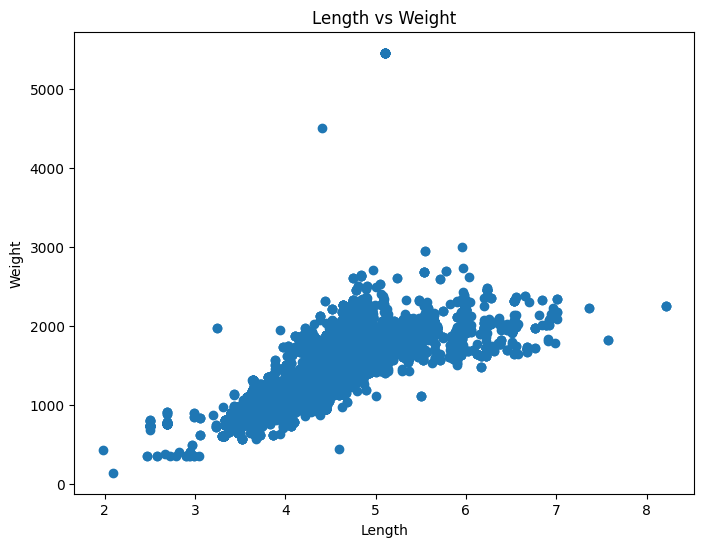

In [119]:
plt.figure(figsize=(8, 6))
plt.scatter(train["Length"], train["Weight"])

plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Length vs Weight")

plt.show()

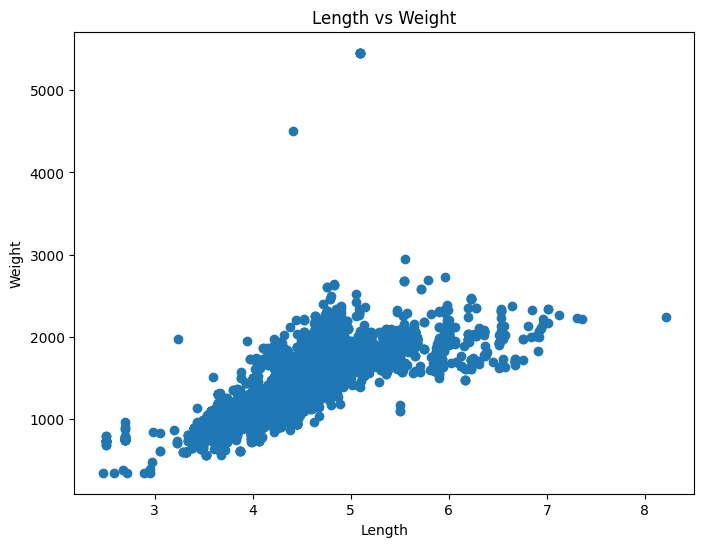

In [124]:
plt.figure(figsize=(8, 6))
plt.scatter(test["Length"], test["Weight"])

plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Length vs Weight")

plt.show()

In [133]:
cars = df[[
    "Power",
    "Cylinder_capacity",
    "Value_vehicle",
    "N_doors",
    "Type_fuel",
    "Length",
    "Weight"
]].copy()

In [134]:
cars.duplicated().sum()

np.int64(83407)

In [135]:
print("Ukupno redova:", len(cars))
print("Unique redova:", len(cars.drop_duplicates()))
print("Duplikata:", cars.duplicated().sum())

Ukupno redova: 105555
Unique redova: 22148
Duplikata: 83407


In [136]:
cars = cars.drop_duplicates()

In [137]:
cars

,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,80,599,7068.00,0,P,NaN,190
6,85,1229,16030.00,5,P,3.999,1105
10,6,74,1261.82,0,P,NaN,87
13,6,244,3000.00,0,P,NaN,92
15,87,1598,9927.00,4,P,4.250,1055
...,...,...,...,...,...,...,...
105536,224,2987,58300.00,5,D,4.884,1810
105537,130,1199,29465.00,5,P,4.602,1395
105538,95,1870,18721.53,5,D,NaN,1300
105548,11,505,10217.21,3,P,NaN,400


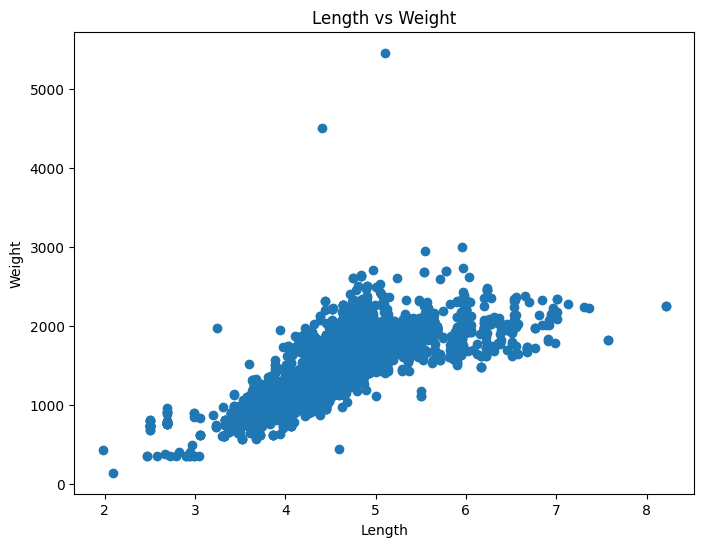

In [138]:
plt.figure(figsize=(8, 6))
plt.scatter(cars["Length"], cars["Weight"])

plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Length vs Weight")

plt.show()

In [139]:
cars.isna().sum()

Power                   0
Cylinder_capacity       0
Value_vehicle           0
N_doors                 0
Type_fuel             522
Length               2363
Weight                  0
dtype: int64

In [142]:
from sklearn.linear_model import LinearRegression

# uzmi samo redove gde length NIJE null
df_train = df[df["Length"].notna()]

X_train = df_train[["Weight", "Value_vehicle", "Cylinder_capacity"]]
y_train = df_train["Length"]

In [143]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

In [144]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
cars_missing = cars[cars["Length"].isna()]

X_missing = cars_missing[["Weight"]]

In [146]:
X_missing = X_missing.fillna(X_train.mean())

In [147]:
predicted_length = model.predict(X_missing)

In [148]:
cars.loc[cars["Length"].isna(), "Length"] = predicted_length

In [149]:
cars["Length"].isna().sum()

np.int64(0)

In [150]:
model.score(X_train, y_train)

0.6847321630348246

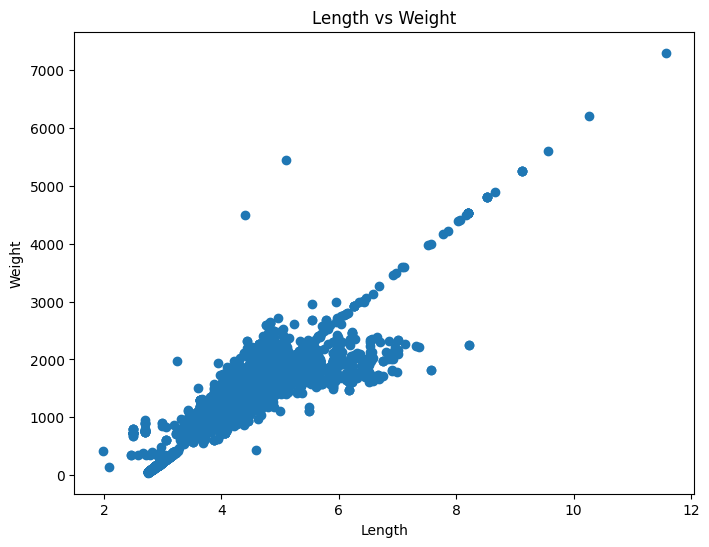

In [151]:
plt.figure(figsize=(8, 6))
plt.scatter(cars["Length"], cars["Weight"])

plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Length vs Weight")

plt.show()

In [156]:
cars["log_Premium"] = np.log1p(df["Premium"])

In [157]:
cars[['length_power','log_Premium']].corr()

,length_power,log_Premium
length_power,1.000000,0.443982
log_Premium,0.443982,1.000000
